# Retail Sales Data - Exploratory Data Analysis

## 1. Introduction

This project focuses on performing Exploratory Data Analysis (EDA) on a retail sales dataset.

The main objective is to explore sales trends, customer behaviour, product performance, and relationships between numerical variables.

The analysis includes data inspection, descriptive statistics, time series analysis, customer demographics, product analysis, correlation analysis, and additional visualizations.

The findings will be used to identify meaningful patterns and provide actionable business recommendations.

## 2. Import Libraries

In this section, the required Python libraries are imported for data analysis and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Data Loading, Inspection and Cleaning

In this section, the retail sales dataset is loaded into a pandas DataFrame and its general structure is examined. The number of rows and columns, data types, missing values, and duplicate records are checked. The dataset is then prepared for further analysis, and the date column is converted to the appropriate datetime format.

In [4]:
df = pd.read_csv("Retail_data.csv", sep=None, engine="python")
df.head()

,﻿OrderID,OrderDate,ProductID,StoreID,CustomerID,Quantity,Sales,Discount,Gender,AgeGroup,ProductName,Category,Brand,Cost,StoreName,City,Region
0,62,18.02.2023,P5,S5,C111,2,"4,37",0,Female,18-25,Bizim Tarla Pomidor konservi,Canned,Bizim Tarla,"1,5",Spar,Baku,East
1,68,17.12.2023,P2,S5,C292,2,"5,18","0,1",Female,50+,Azərsun Günəbaxan Yağı 1L,Grocery,Azersun,"2,5",Spar,Baku,East
2,89,30.07.2023,P1,S5,C137,2,"2,33",0,Male,50+,Coca-Cola 1L,Beverage,Coca-Cola,"0,8",Spar,Baku,East
3,144,12.06.2023,P7,S5,C185,2,"0,68",0,Male,26-35,Sərin Çörək,Bakery,Local,"0,4",Spar,Baku,East
4,315,18.03.2023,P3,S5,C285,2,"2,54","0,05",Male,50+,Milla Süd 1L,Dairy,Milla,"1,2",Spar,Baku,East


In [5]:
df.shape

(2000, 17)

In [7]:
df.columns.tolist()

['\ufeffOrderID',
 'OrderDate',
 'ProductID',
 'StoreID',
 'CustomerID',
 'Quantity',
 'Sales',
 'Discount',
 'Gender',
 'AgeGroup',
 'ProductName',
 'Category',
 'Brand',
 'Cost',
 'StoreName',
 'City',
 'Region']

In [8]:
df.isnull().sum()

,0
﻿OrderID,0
OrderDate,0
ProductID,0
StoreID,0
CustomerID,0
Quantity,0
Sales,0
Discount,0
Gender,0
AgeGroup,0


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ﻿OrderID     2000 non-null   int64 
 1   OrderDate    2000 non-null   object
 2   ProductID    2000 non-null   object
 3   StoreID      2000 non-null   object
 4   CustomerID   2000 non-null   object
 5   Quantity     2000 non-null   int64 
 6   Sales        2000 non-null   object
 7   Discount     2000 non-null   object
 8   Gender       2000 non-null   object
 9   AgeGroup     2000 non-null   object
 10  ProductName  2000 non-null   object
 11  Category     2000 non-null   object
 12  Brand        2000 non-null   object
 13  Cost         2000 non-null   object
 14  StoreName    2000 non-null   object
 15  City         2000 non-null   object
 16  Region       2000 non-null   object
dtypes: int64(2), object(15)
memory usage: 265.8+ KB


In [18]:
df["OrderDate"]=pd.to_datetime(df["OrderDate"])

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   ﻿OrderID     2000 non-null   int64         
 1   OrderDate    2000 non-null   datetime64[ns]
 2   ProductID    2000 non-null   object        
 3   StoreID      2000 non-null   object        
 4   CustomerID   2000 non-null   object        
 5   Quantity     2000 non-null   int64         
 6   Sales        2000 non-null   object        
 7   Discount     2000 non-null   object        
 8   Gender       2000 non-null   object        
 9   AgeGroup     2000 non-null   object        
 10  ProductName  2000 non-null   object        
 11  Category     2000 non-null   object        
 12  Brand        2000 non-null   object        
 13  Cost         2000 non-null   object        
 14  StoreName    2000 non-null   object        
 15  City         2000 non-null   object        
 16  Region

In [17]:
df.describe()

,﻿OrderID,OrderDate,Quantity
count,2000.000000,2000,2000.0000
mean,1000.500000,2023-12-20 17:37:40.800000,3.0035
min,1.000000,2023-01-02 00:00:00,1.0000
25%,500.750000,2023-07-07 00:00:00,2.0000
50%,1000.500000,2023-12-17 00:00:00,3.0000
75%,1500.250000,2024-05-31 00:00:00,4.0000
max,2000.000000,2024-12-30 00:00:00,5.0000
std,577.494589,NaN,1.4158


In [15]:
df.duplicated().sum()

np.int64(0)

## 4. Descriptive Statistics

In this section, descriptive statistics are calculated for the numerical variables in the dataset. Mean, median, mode, and standard deviation are used to understand the central tendency and variability of the data.

In [28]:
df["Sales"]=pd.to_numeric(df["Sales"].astype(str).str.replace(",",".",regex=False))
df["Discount"]=pd.to_numeric(df["Discount"].astype(str).str.replace(",",".",regex=False))

In [29]:
df.dtypes

,0
﻿OrderID,int64
OrderDate,datetime64[ns]
ProductID,object
StoreID,object
CustomerID,object
Quantity,int64
Sales,float64
Discount,float64
Gender,object
AgeGroup,object


In [80]:
numeric_colums=df.select_dtypes(include=np.number)
numeric_colums.head()

,﻿OrderID,Quantity,Sales,Discount
0,62,2,4.37,0.00
1,68,2,5.18,0.10
2,89,2,2.33,0.00
3,144,2,0.68,0.00
4,315,2,2.54,0.05


In [36]:
Mean_values=df[numeric_colums].mean()
Median_values=df[numeric_colums].median()
Mode_values=df[numeric_colums].mode().iloc[0]
STD_values=df[numeric_colums].std()

print(f" Mean Values: {Mean_values}")
print(f" Median Values: {Median_values}")
print(f" Mode Values: {Mode_values}")
print(f" STD Values: {STD_values}")


 Mean Values: ﻿OrderID    1000.500000
Quantity       3.003500
Sales          4.189020
Discount       0.075975
dtype: float64
 Median Values: ﻿OrderID    1000.500
Quantity       3.000
Sales          3.575
Discount       0.100
dtype: float64
 Mode Values: ﻿OrderID    1.00
Quantity    4.00
Sales       2.26
Discount    0.15
Name: 0, dtype: float64
 STD Values: ﻿OrderID    577.494589
Quantity      1.415800
Sales         2.700829
Discount      0.056108
dtype: float64


## 5. Monthly Sales Analysis

In this section, monthly sales are analyzed to identify sales trends and changes over time. A line chart is used to visualize the monthly sales performance.

In [39]:
monthly_sales=df.resample("ME",on="OrderDate")["Sales"].sum()
monthly_sales

,Sales
OrderDate,
2023-01-31,314.45
2023-02-28,326.78
2023-03-31,368.63
2023-04-30,287.96
2023-05-31,364.65
2023-06-30,345.69
2023-07-31,418.24
2023-08-31,390.05
2023-09-30,309.46


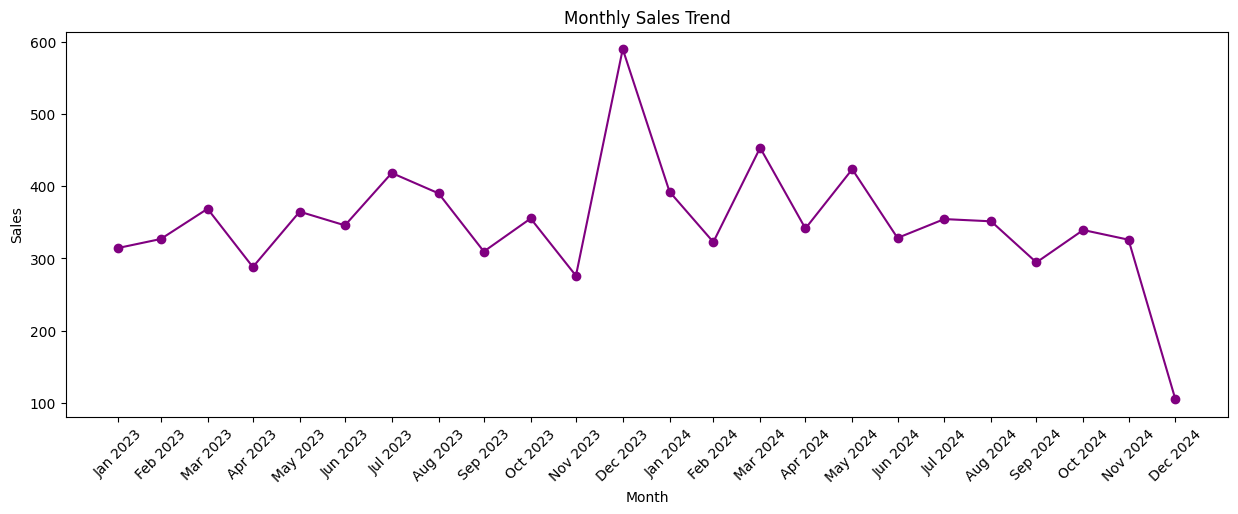

In [93]:
plt.figure(figsize=(15,5))
plt.plot(monthly_sales.index,monthly_sales.values,marker="o",color="purple")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(
    monthly_sales.index,
    monthly_sales.index.strftime("%b %Y"),
    rotation=45)
plt.show()

## 6. Quarterly Sales Analysis

In this section, sales performance is analyzed on a quarterly basis to identify broader seasonal patterns and changes in revenue over time. A line chart is used to visualize quarterly sales trends.

In [44]:
quarterly_sales=df.resample("QE",on="OrderDate")["Sales"].sum()
quarterly_sales

,Sales
OrderDate,
2023-03-31,1009.86
2023-06-30,998.30
2023-09-30,1117.75
2023-12-31,1221.02
2024-03-31,1167.96
2024-06-30,1093.01
2024-09-30,1000.00
2024-12-31,770.14


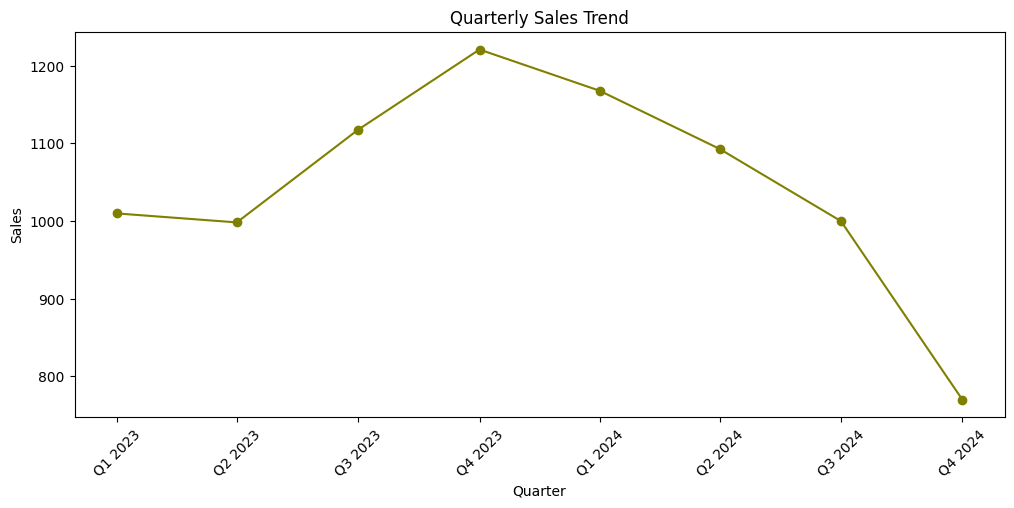

In [91]:
plt.figure(figsize=(12,5))
plt.plot(quarterly_sales.index,quarterly_sales.values,marker="o",color="olive")
plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Sales")
quarterly_labels=[f"Q{date.quarter} {date.year}"
    for date in quarterly_sales.index]
plt.xticks(
    quarterly_sales.index,
    quarterly_labels,
    rotation=45)
plt.show()

## 7. Customer Demographics

In this section, customer demographics are analyzed based on age groups and gender. The distribution of customers across different demographic groups is visualized to better understand the customer base.

In [53]:
age_distrubition=df["AgeGroup"].value_counts()
age_distrubition

,count
AgeGroup,
36-50,616
26-35,525
50+,433
18-25,426


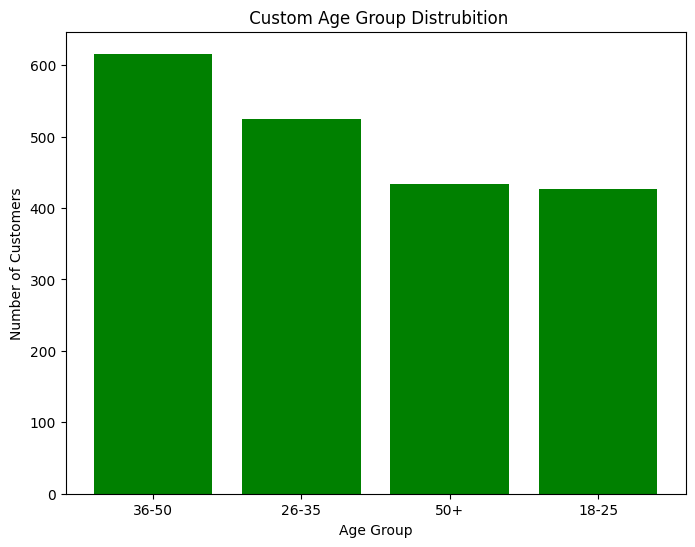

In [58]:
plt.figure(figsize=(8,6))
plt.bar(age_distrubition.index,age_distrubition.values,color="green")
plt.title(" Custom Age Group Distrubition")
plt.ylabel("Number of Customers")
plt.xlabel("Age Group")
plt.show()

In [59]:
gender_distrubition=df["Gender"].value_counts()
gender_distrubition

,count
Gender,
Male,1015
Female,985


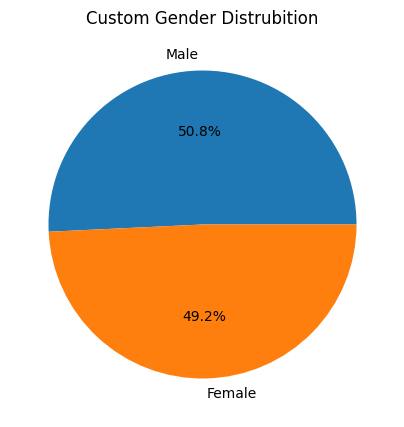

In [89]:
plt.figure(figsize=(5,5))
plt.pie(gender_distrubition,
        labels=gender_distrubition.index,
        autopct="%1.1f%%")
plt.title("Custom Gender Distrubition")
plt.show()

## 8. Product Analysis

In this section, product performance is analyzed to identify the best-selling products and the revenue generated by different product categories.

In [64]:
top_product=df.groupby("ProductName")["Quantity"].sum().sort_values(ascending=False).head(10)
top_product

,Quantity
ProductName,
Azərsun Günəbaxan Yağı 1L,727
Çudo Şokoladlı desert,644
Bizim Tarla Pomidor konservi,621
Milla Süd 1L,610
Coca-Cola 1L,609
Red Bull 250ml,599
Sərin Çörək,580
Pringles Chips,573
Savalan Toyuq filesi,554


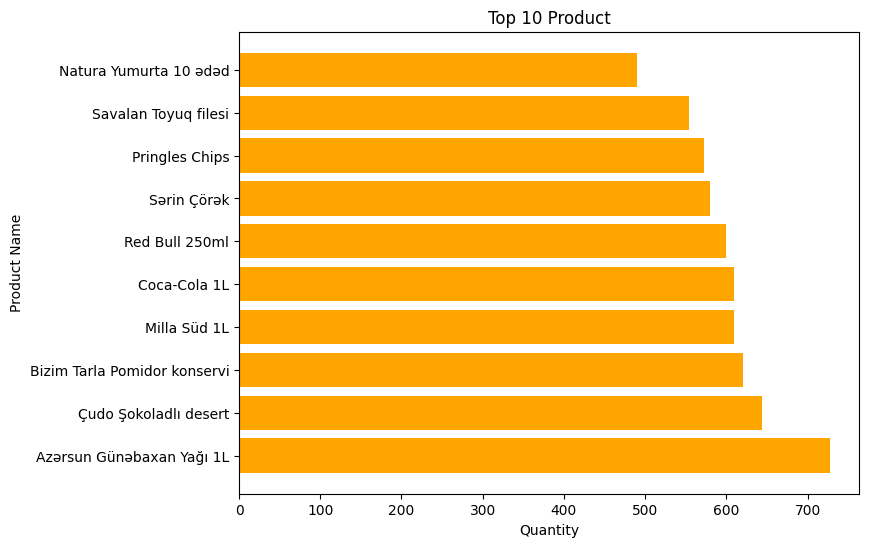

In [88]:
plt.figure(figsize=(8,6))
plt.barh(top_product.index,top_product.values,color="orange")
plt.title("Top 10 Product")
plt.ylabel("Product Name")
plt.xlabel("Quantity")
plt.show()

## 9. Sales by Product Category

This analysis examines the revenue generated by each product category. A bar chart is used to compare the revenue contribution of different categories.

In [72]:
sales_by_category=df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
sales_by_category

,Sales
Category,
Meat,1922.66
Snack,1751.42
Grocery,1367.93
Dairy,1362.97
Beverage,1094.15
Canned,701.84
Bakery,177.07


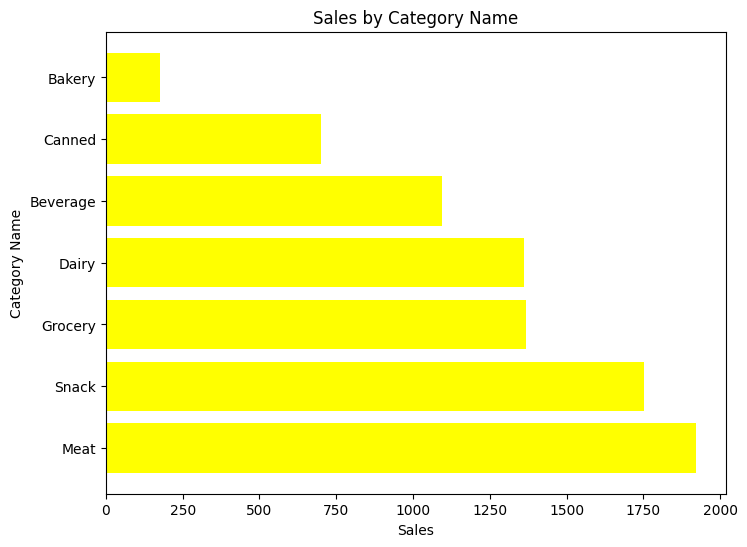

In [87]:
plt.figure(figsize=(8,6))
plt.barh(sales_by_category.index,sales_by_category.values,color="yellow")
plt.title("Sales by Category Name")
plt.ylabel("Category Name")
plt.xlabel("Sales")
plt.show()

## 10. Correlation Heatmap

In this section, the correlation between numerical variables is analyzed using a correlation matrix. A heatmap is used to visualize the strength and direction of relationships between numerical variables.

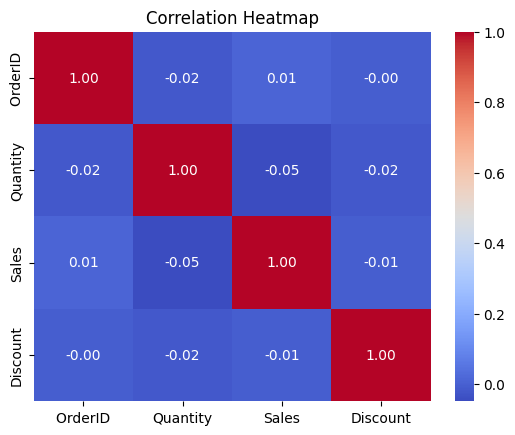

In [81]:
sns.heatmap(numeric_colums.corr(),annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

### Observation

The correlation between Discount and Sales is -0.01, while the correlation between Discount and Quantity is -0.02. These values indicate very weak negative relationships, suggesting that discount has almost no linear relationship with sales or quantity in this dataset.

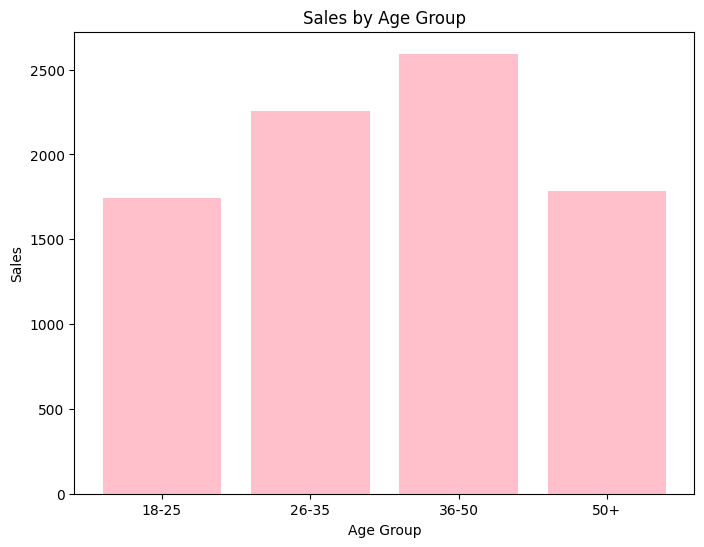

In [86]:
age_sales=df.groupby("AgeGroup")["Sales"].sum()
plt.figure(figsize=(8,6))
plt.bar(age_sales.index,age_sales.values,color="pink")
plt.title("Sales by Age Group")
plt.ylabel("Sales")
plt.xlabel("Age Group")
plt.show()


## 11. Key Findings

### 1. Monthly Sales
The highest monthly sales were recorded in December 2023, while the lowest sales were recorded in December 2024.

### 2. Quarterly Sales
The highest quarterly sales were recorded in Q4 2023, while the lowest sales were recorded in Q4 2024.

### 3. Customer Age Groups
Customers aged 36–50 represent the largest age group, while customers aged 18–25 represent the smallest age group.

### 4. Customer Gender
Male customers represent 50.8% of the customer base, while female customers represent 49.2%. The gender distribution is relatively balanced.

### 5. Best-Selling Product
Azərsun Günəbaxan Yağı 1L was the best-selling product, with 727 units sold.

### 6. Revenue by Product Category
The Meat category generated the highest revenue at 1922.66, while the Bakery category generated the lowest revenue at 177.07.

### 7. Correlation Analysis
The correlation between Order ID and Sales was 0.01, indicating an almost nonexistent linear relationship. The correlations between Discount and Sales (-0.01) and Discount and Quantity (-0.02) were also very weak.

### 8. Revenue by Age Group
Customers aged 36–50 generated the highest revenue, while customers aged 18–25 generated the lowest revenue.



## 12. Business Recommendations

Based on the findings from the exploratory data analysis, the following business recommendations can be made:

1. Focus on High-Performing Products
   Since Azərsun Günəbaxan Yağı 1L was the best-selling product with 727 units sold, the business should ensure sufficient stock availability and consider promoting similar high-demand products.

2. Strengthen High-Revenue Categories
   The Meat category generated the highest revenue, while Bakery generated the lowest. The business should maintain strong inventory and promotional strategies for high-revenue categories and investigate ways to improve the performance of lower-revenue categories.

3. Target the 36–50 Age Group
   Customers aged 36–50 generated the highest revenue. Marketing campaigns, product recommendations, and promotions can be designed to better target this customer segment.

4. Improve Engagement with Younger Customers
   Customers aged 18–25 generated the lowest revenue. The business could introduce targeted promotions, discounts, and product campaigns to increase engagement and purchasing activity among younger customers.
